# ⚽ FIFA Player Rating Prediction Model

This notebook builds machine learning models to predict a player's tournament rating (`player_rating`) based on their physical attributes and match performance statistics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

### Step 1: Load and Explore Dataset

In [2]:
# Load player performance dataset
df = pd.read_csv("fifa_world_cup_2026_player_performance.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (54600, 75)


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [3]:
# Describe the target variable
df["player_rating"].describe()

count    54600.000000
mean         3.634700
std          3.155846
min          0.000000
25%          0.000000
50%          5.500000
75%          6.400000
max          9.400000
Name: player_rating, dtype: float64

### Step 2: Feature Selection & Correlation Analysis

In [4]:
# Define numerical performance and physical features
feature_cols = [
    "age", "height_cm", "weight_kg", "minutes_played", 
    "goals", "assists", "shots", "pass_accuracy", 
    "tackles", "interceptions", "clearances", "saves", 
    "distance_covered_km", "top_speed_kmh", "stamina_score"
]

# Create clean sub-dataframe
clean_df = df[feature_cols + ["player_rating"]].dropna()
print(f"Cleaned dataset shape: {clean_df.shape}")

Cleaned dataset shape: (54600, 16)


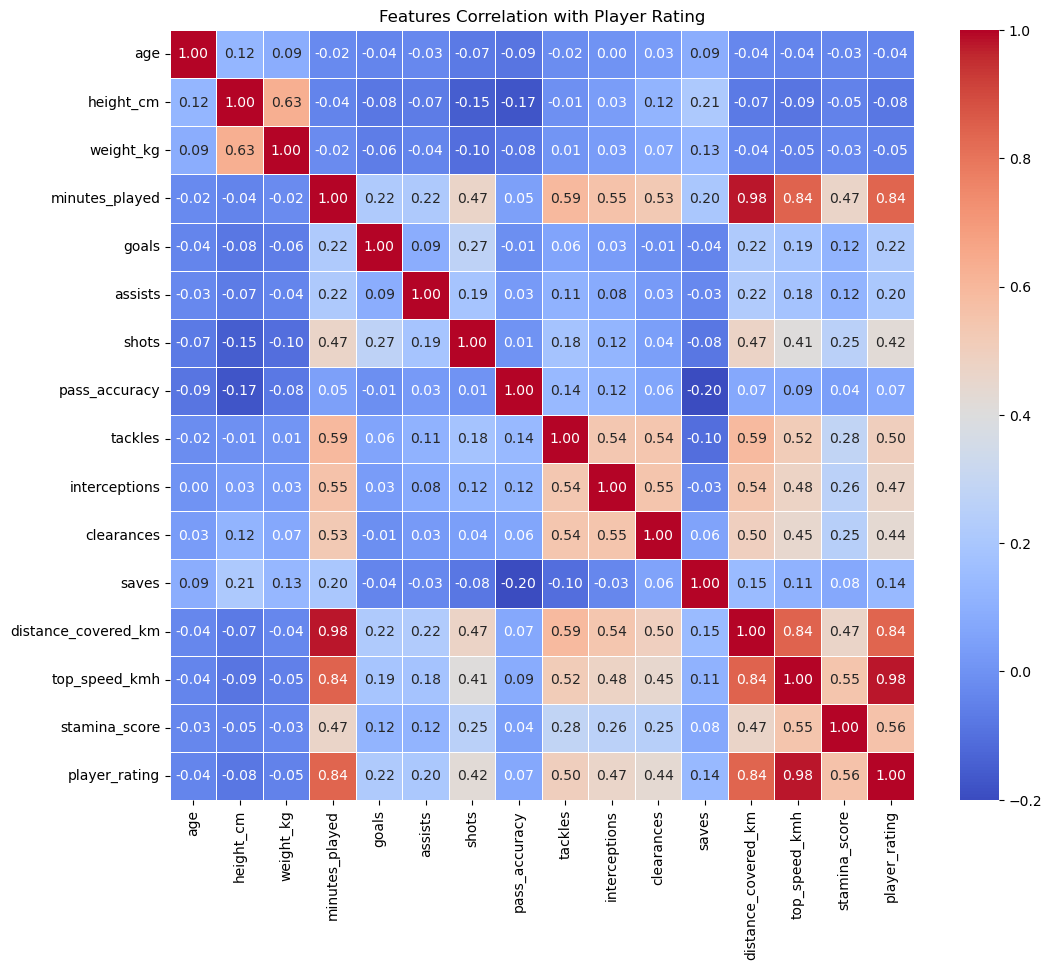

In [5]:
# Plot Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(clean_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Features Correlation with Player Rating")
plt.show()

### Step 3: Train-Test Split

In [6]:
X = clean_df[feature_cols]
y = clean_df["player_rating"]

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (43680, 15)
X_test shape: (10920, 15)


### Step 4: Model Training

In [7]:
# Initialize models
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)

# Fit models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

# Predict on test set
lr_preds = lr_model.predict(X_test)
dt_preds = dt_model.predict(X_test)

### Step 5: Model Evaluation & Comparison

In [8]:
# Calculate metrics
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_preds)

dt_mse = mean_squared_error(y_test, dt_preds)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_preds)

print("--- Linear Regression Evaluation ---")
print(f"Mean Squared Error: {lr_mse:.4f}")
print(f"Root Mean Squared Error: {lr_rmse:.4f}")
print(f"R2 Score: {lr_r2:.4f}")

print("\n--- Decision Tree Regressor Evaluation ---")
print(f"Mean Squared Error: {dt_mse:.4f}")
print(f"Root Mean Squared Error: {dt_rmse:.4f}")
print(f"R2 Score: {dt_r2:.4f}")

--- Linear Regression Evaluation ---
Mean Squared Error: 0.3674
Root Mean Squared Error: 0.6062
R2 Score: 0.9632

--- Decision Tree Regressor Evaluation ---
Mean Squared Error: 0.2907
Root Mean Squared Error: 0.5391
R2 Score: 0.9709


### Step 6: Visualizing Results

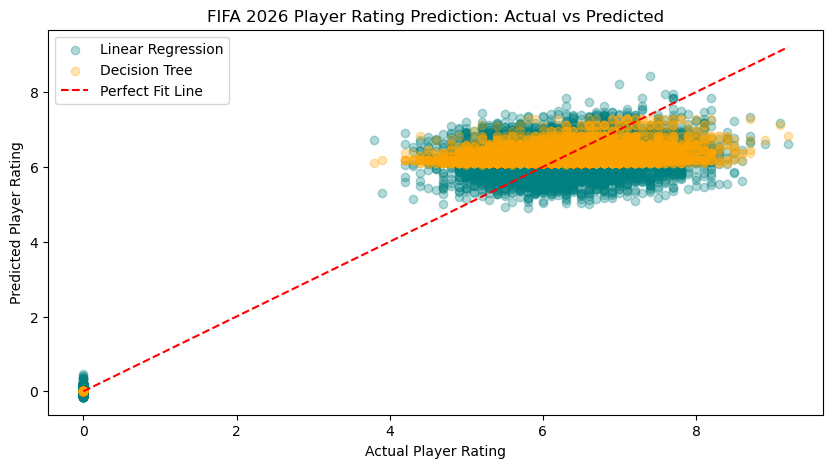

In [9]:
# Plot Actual vs Predicted player ratings
plt.figure(figsize=(10, 5))
plt.scatter(y_test, lr_preds, color="teal", alpha=0.3, label="Linear Regression")
plt.scatter(y_test, dt_preds, color="orange", alpha=0.3, label="Decision Tree")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Perfect Fit Line")
plt.xlabel("Actual Player Rating")
plt.ylabel("Predicted Player Rating")
plt.title("FIFA 2026 Player Rating Prediction: Actual vs Predicted")
plt.legend()
plt.show()